# Explore here

TRABAJO POR GOOGLE COLAB

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split

In [ ]:
# 1. Verificación de archivos
train_dir = "/content/data/train"
test_dir = "/content/data/test1"

# Listar archivos (debes tener etiquetas de alguna forma)
train_files = [f for f in os.listdir(train_dir) if f.endswith(('.jpg', '.png'))]
test_files = [f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.png'))]

print(f"Imágenes en train: {len(train_files)}")
print(f"Imágenes en test: {len(test_files)}")


Imágenes en train: 0
Imágenes en test: 12500


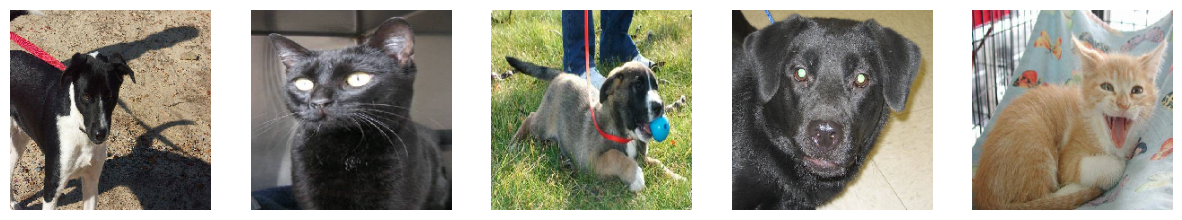

In [ ]:
# 2. Visualización de imágenes de ejemplo
plt.figure(figsize=(15, 5))
for i in range(5):
    img_path = os.path.join(test_dir, test_files[i])
    img = load_img(img_path, target_size=(224, 224))
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
plt.show()

#NOTAA : ejecuté dos veces esta celda, ya se cambiaron los archivos

In [ ]:
# 3. Crear estructura temporal con subcarpetas por clase
os.makedirs("/content/data_temp/train/class0", exist_ok=True)
os.makedirs("/content/data_temp/train/class1", exist_ok=True)

# Ejemplo: clasificar basado en nombres de archivo
for f in train_files:
    if "dog" in f.lower():
        os.rename(os.path.join(train_dir, f), os.path.join("/content/data_temp/train/class0", f))
    else:
        os.rename(os.path.join(train_dir, f), os.path.join("/content/data_temp/train/class1", f))


In [ ]:
# 4. Generadores con la nueva estructura
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

trdata = train_datagen.flow_from_directory(
    '/content/data_temp/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

valdata = train_datagen.flow_from_directory(
    '/content/data_temp/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [ ]:
# 5. Modelo (ajustado a 2 clases)
model = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    MaxPool2D(2,2),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPool2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(2, activation='softmax')  # 2 clases
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
checkpoint = ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True)
history = model.fit(
    trdata,
    validation_data=valdata,
    epochs=10,
    callbacks=[checkpoint]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5622 - loss: 1.5897

625/625 ━━━━━━━━━━━━━━━━━━━━ 4642s 7s/step - accuracy: 0.5623 - loss: 1.5885 - val_accuracy: 0.6664 - val_loss: 0.6146
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6859 - loss: 0.5858

625/625 ━━━━━━━━━━━━━━━━━━━━ 4775s 8s/step - accuracy: 0.6859 - loss: 0.5858 - val_accuracy: 0.7078 - val_loss: 0.5673
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7718 - loss: 0.4745

625/625 ━━━━━━━━━━━━━━━━━━━━ 4499s 7s/step - accuracy: 0.7718 - loss: 0.4745 - val_accuracy: 0.7162 - val_loss: 0.5728
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8782 - loss: 0.2977

625/625 ━━━━━━━━━━━━━━━━━━━━ 4513s 7s/step - accuracy: 0.8782 - loss: 0.2977 - val_accuracy: 0.7202 - val_loss: 0.6400
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9595 - loss: 0.1167

625/625 ━━━━━━━━━━━━━━━━━━━━ 4557s 7s/step - accuracy: 0.9595 - loss: 0.1167 - val_accuracy: 0.7278 - val_loss: 1.0491
Epoch 6/10
 53/625 ━━━━━━━━━━━━━━━━━━━━ 1:05:24 7s/step - accuracy: 0.9898 - loss: 0.0452

KeyboardInterrupt: 

**## Interrumpí el proceso porque ya  Val_acuraccy no mejoraba significativamente:**

In [ ]:
from tensorflow.keras.models import load_model
mejor_modelo = load_model("best_model.h5")  # Cargará el modelo con mejor val_accuracy

In [ ]:
loss, accuracy = mejor_modelo.evaluate(valdata)
print(f"Precisión del mejor modelo: {accuracy:.2f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.7391 - loss: 1.0316
Precisión del mejor modelo: 0.73


**Busqué mejorar el codigo hecho en clases:**

*   accuracy: 0.5023
*   loss: 0.7023

**Bajo metodología Sequencial se logró:**

*   accuracy: 0.7391
*   loss: 1.0316

